## Projekt 1: Model SIR hapesinor ne rrjet, difusion lokal dhe karantine.

**Punoi studenti:** Klaus Dragjoshi

**Lende me zgjedhje:** Modelim ne Fizike

### Qellimi: Te ndertohet modeli SIR nga perzierje homogjene ne nje rrjet ose rrjete dy-dimensionale ku infektimi ndodh kryesisht lokalisht.

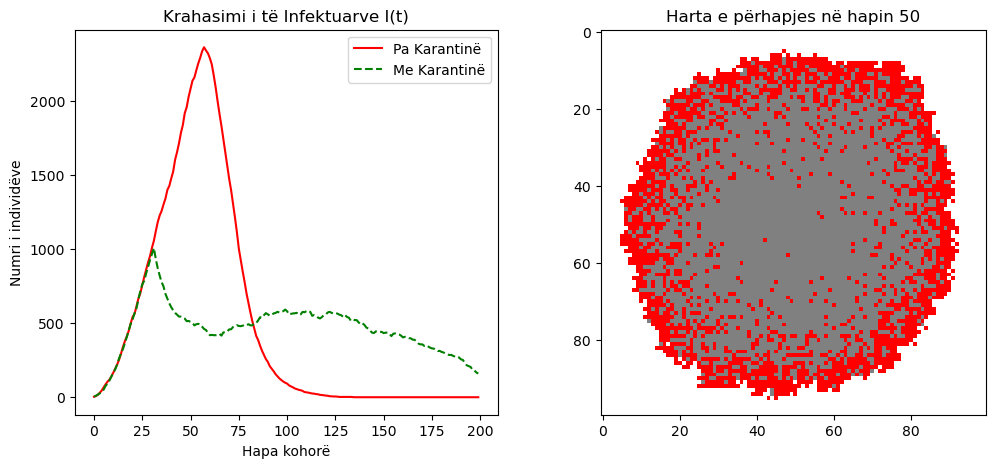

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# --- PARAMETRAT E MODELIT ---
N = 100          # Madhësia e rrjetës (100x100)
beta = 0.3       # Probabiliteti i transmetimit 
gamma = 0.1      # Probabiliteti i shërimit
steps = 200      # Numri i hapave kohorë
quarantine_threshold = 0.1 

# Gjendjet
S, I, R = 0, 1, 2

def run_simulation(use_quarantine=False):
    # 1. Krijimi i rrjetës dhe gjendjeve diskrete 
    grid = np.zeros((N, N), dtype=int)
    
    # Eksperimenti i Vatres qendrore
    grid[N//2, N//2] = I
    
    # Ruajtja e historikut
    s_counts, i_counts, r_counts = [], [], []
    history_grids = []

    current_beta = beta

    for t in range(steps):
        new_grid = grid.copy()
        n_infected_total = np.sum(grid == I)
        
        # 3. Nese kemi karantine globale 
        if use_quarantine and (n_infected_total / N**2) > quarantine_threshold:
            current_beta = beta * 0.2  # Ulim lidhjet/transmetimin
        
        
        for r in range(N):
            for c in range(N):
                if grid[r, c] == S:
                    # Numërimi i fqinjëve kemi 8 fqinj.
                    neighbors = grid[max(0,r-1):min(N,r+2), max(0,c-1):min(N,c+2)]
                    n_i = np.sum(neighbors == I)
                    
                    # Formula: P(S->I) = 1 - (1-beta)^nI
                    prob_inf = 1 - (1 - current_beta)**n_i
                    if np.random.rand() < prob_inf:
                        new_grid[r, c] = I
                        
                elif grid[r, c] == I:
                    # Kalimi në R me probabilitet gamma
                    if np.random.rand() < gamma:
                        new_grid[r, c] = R
        
        grid = new_grid
        
        # Ruajtja e të dhënave
        s_counts.append(np.sum(grid == S))
        i_counts.append(np.sum(grid == I))
        r_counts.append(np.sum(grid == R))
        
        if t in [0, 20, 50, 100]: 
            history_grids.append((t, grid.copy()))

    return s_counts, i_counts, r_counts, history_grids

# Ekzekutimi i dy skenarëve
s_norm, i_norm, r_norm, maps_norm = run_simulation(use_quarantine=False)
s_quar, i_quar, r_quar, maps_quar = run_simulation(use_quarantine=True)

# --- VIZUALIZIMI ---

# Grafikët e kurbave S(t), I(t), R(t)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(i_norm, label='Pa Karantinë', color='red')
plt.plot(i_quar, label='Me Karantinë', color='green', linestyle='--')
plt.title('Krahasimi i të Infektuarve I(t)')
plt.xlabel('Hapa kohorë')
plt.ylabel('Numri i individëve')
plt.legend()

# Shfaqja e hartave të gjendjes 
cmap = colors.ListedColormap(['white', 'red', 'gray']) # S=white, I=red, R=gray
plt.subplot(1, 2, 2)
plt.imshow(maps_norm[2][1], cmap=cmap)
plt.title(f'Harta e përhapjes në hapin {maps_norm[2][0]}')
plt.show()